In [1]:
from pathlib import Path

# Detect project root
current_path = Path.cwd()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

SRC_DIR = PROJECT_ROOT / "src"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORT_DIR = PROJECT_ROOT / "report"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Make sure folders exist
for folder in [SRC_DIR, FIGURES_DIR, REPORT_DIR, NOTEBOOKS_DIR]:
    folder.mkdir(exist_ok=True)

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("Source folder:", SRC_DIR)
print("Figures folder:", FIGURES_DIR)
print("Report folder:", REPORT_DIR)
print("Notebooks folder:", NOTEBOOKS_DIR)

Current path: C:\Users\FATI\Desktop\ml_project_kmeans\notebooks
Project root: C:\Users\FATI\Desktop\ml_project_kmeans
Source folder: C:\Users\FATI\Desktop\ml_project_kmeans\src
Figures folder: C:\Users\FATI\Desktop\ml_project_kmeans\figures
Report folder: C:\Users\FATI\Desktop\ml_project_kmeans\report
Notebooks folder: C:\Users\FATI\Desktop\ml_project_kmeans\notebooks


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SRC_DIR = PROJECT_ROOT / "src"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORT_DIR = PROJECT_ROOT / "report"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Create main project files
files_to_create = [
    SRC_DIR / "__init__.py",
    SRC_DIR / "kmeans.py",
    SRC_DIR / "kmeanspp.py",
    SRC_DIR / "utils.py",
    PROJECT_ROOT / "requirements.txt",
    PROJECT_ROOT / "README.md",
]

for file_path in files_to_create:
    if not file_path.exists():
        file_path.write_text("", encoding="utf-8")

# Write requirements.txt
requirements_text = """numpy
matplotlib
scikit-learn
pandas
jupyter
ipykernel
"""

(PROJECT_ROOT / "requirements.txt").write_text(requirements_text, encoding="utf-8")

print("Project files created successfully:")
for file_path in files_to_create:
    print("-", file_path.relative_to(PROJECT_ROOT))

Project files created successfully:
- src\__init__.py
- src\kmeans.py
- src\kmeanspp.py
- src\utils.py
- requirements.txt
- README.md


In [3]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

kmeans_code = r'''
import numpy as np


def squared_euclidean_distances(X, centers):
    """
    Compute squared Euclidean distances between each data point and each center.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Dataset.
    centers : array-like, shape (n_clusters, n_features)
        Cluster centers.

    Returns
    -------
    distances : ndarray, shape (n_samples, n_clusters)
        distances[i, j] is the squared distance between X[i] and centers[j].
    """
    X = np.asarray(X, dtype=float)
    centers = np.asarray(centers, dtype=float)

    return np.sum((X[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)


class KMeansScratch:
    """
    K-Means implemented from scratch using NumPy.

    This implementation does not use sklearn.fit().
    It supports random initialization and stores:
    - final cluster centers
    - final labels
    - final inertia
    - inertia history over iterations
    - number of iterations
    """

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        if not isinstance(n_clusters, int) or n_clusters <= 0:
            raise ValueError("n_clusters must be a positive integer.")

        if max_iter <= 0:
            raise ValueError("max_iter must be positive.")

        if tol < 0:
            raise ValueError("tol must be non-negative.")

        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.inertia_history_ = []
        self.n_iter_ = 0

    def _validate_data(self, X):
        X = np.asarray(X, dtype=float)

        if X.ndim != 2:
            raise ValueError("X must be a 2D array with shape (n_samples, n_features).")

        n_samples, n_features = X.shape

        if n_samples == 0:
            raise ValueError("X must contain at least one sample.")

        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot be larger than the number of samples.")

        return X

    def _initialize_random_centroids(self, X, rng):
        """
        Randomly select k different points from X as initial centroids.
        """
        n_samples = X.shape[0]
        indices = rng.choice(n_samples, size=self.n_clusters, replace=False)
        return X[indices].copy()

    def _assign_labels(self, X, centroids):
        """
        Assign each point to the nearest centroid.
        """
        distances = squared_euclidean_distances(X, centroids)
        labels = np.argmin(distances, axis=1)
        return labels

    def _compute_inertia(self, X, centroids, labels):
        """
        Compute the K-Means objective:
        sum of squared distances from each point to its assigned centroid.
        """
        return float(np.sum((X - centroids[labels]) ** 2))

    def _update_centroids(self, X, labels, old_centroids, rng):
        """
        Update each centroid as the mean of the assigned points.

        If a cluster becomes empty, reinitialize that centroid using
        the point that is farthest from its nearest current centroid.
        This avoids crashes during difficult random initializations.
        """
        new_centroids = np.empty_like(old_centroids)

        distances_to_old = squared_euclidean_distances(X, old_centroids)
        nearest_old_distance = np.min(distances_to_old, axis=1)

        for cluster_id in range(self.n_clusters):
            points_in_cluster = X[labels == cluster_id]

            if len(points_in_cluster) > 0:
                new_centroids[cluster_id] = np.mean(points_in_cluster, axis=0)
            else:
                farthest_index = np.argmax(nearest_old_distance)
                new_centroids[cluster_id] = X[farthest_index]

        return new_centroids

    def fit(self, X, initial_centroids=None):
        """
        Fit K-Means to data X.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Dataset.
        initial_centroids : optional ndarray, shape (n_clusters, n_features)
            If provided, these centers are used instead of random initialization.
            This will be useful later for K-Means++.
        """
        X = self._validate_data(X)
        rng = np.random.default_rng(self.random_state)

        if initial_centroids is None:
            centroids = self._initialize_random_centroids(X, rng)
        else:
            centroids = np.asarray(initial_centroids, dtype=float)

            if centroids.shape != (self.n_clusters, X.shape[1]):
                raise ValueError(
                    "initial_centroids must have shape "
                    f"({self.n_clusters}, {X.shape[1]})."
                )

            centroids = centroids.copy()

        self.inertia_history_ = []

        for iteration in range(1, self.max_iter + 1):
            labels = self._assign_labels(X, centroids)
            inertia = self._compute_inertia(X, centroids, labels)
            self.inertia_history_.append(inertia)

            new_centroids = self._update_centroids(X, labels, centroids, rng)
            centroid_shift = np.sqrt(np.sum((new_centroids - centroids) ** 2))

            centroids = new_centroids

            if centroid_shift <= self.tol:
                break

        final_labels = self._assign_labels(X, centroids)
        final_inertia = self._compute_inertia(X, centroids, final_labels)

        if len(self.inertia_history_) == 0 or not np.isclose(self.inertia_history_[-1], final_inertia):
            self.inertia_history_.append(final_inertia)

        self.cluster_centers_ = centroids
        self.labels_ = final_labels
        self.inertia_ = final_inertia
        self.n_iter_ = len(self.inertia_history_)

        return self

    def predict(self, X):
        """
        Assign new points to the nearest fitted centroid.
        """
        if self.cluster_centers_ is None:
            raise ValueError("This KMeansScratch instance is not fitted yet.")

        X = np.asarray(X, dtype=float)

        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        return self._assign_labels(X, self.cluster_centers_)

    def fit_predict(self, X, initial_centroids=None):
        """
        Fit the model and return cluster labels.
        """
        self.fit(X, initial_centroids=initial_centroids)
        return self.labels_
'''

# Write the file
(SRC_DIR / "kmeans.py").write_text(kmeans_code, encoding="utf-8")

# Test import
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.kmeans as kmeans_module
importlib.reload(kmeans_module)

from src.kmeans import KMeansScratch, squared_euclidean_distances

print("kmeans.py written and imported successfully.")
print("Available class:", KMeansScratch.__name__)

kmeans.py written and imported successfully.
Available class: KMeansScratch


In [4]:
import numpy as np
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.kmeans import KMeansScratch

# A very small toy dataset with two obvious clusters
X_toy = np.array([
    [0.0, 0.0],
    [0.2, 0.1],
    [0.1, 0.3],
    [5.0, 5.0],
    [5.2, 5.1],
    [4.9, 5.3]
])

model = KMeansScratch(
    n_clusters=2,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

model.fit(X_toy)

print("Cluster centers:")
print(model.cluster_centers_)

print("\nLabels:")
print(model.labels_)

print("\nFinal inertia:")
print(model.inertia_)

print("\nInertia history:")
print(model.inertia_history_)

print("\nNumber of iterations:")
print(model.n_iter_)

Cluster centers:
[[0.1        0.13333333]
 [5.03333333 5.13333333]]

Labels:
[0 0 0 1 1 1]

Final inertia:
0.15999999999999992

Inertia history:
[0.33, 0.15999999999999992]

Number of iterations:
2


In [5]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

kmeanspp_code = r'''
import numpy as np

from .kmeans import KMeansScratch, squared_euclidean_distances


def initialize_kmeans_pp(X, n_clusters, random_state=None):
    """
    Initialize cluster centers using the k-means++ strategy.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Dataset.
    n_clusters : int
        Number of clusters.
    random_state : int or None
        Random seed for reproducibility.

    Returns
    -------
    centers : ndarray, shape (n_clusters, n_features)
        Initial centers selected by k-means++.
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError("X must be a 2D array.")

    n_samples, n_features = X.shape

    if not isinstance(n_clusters, int) or n_clusters <= 0:
        raise ValueError("n_clusters must be a positive integer.")

    if n_clusters > n_samples:
        raise ValueError("n_clusters cannot be larger than the number of samples.")

    rng = np.random.default_rng(random_state)

    centers = np.empty((n_clusters, n_features), dtype=float)

    # Step 1: choose the first center uniformly at random
    first_index = rng.integers(n_samples)
    centers[0] = X[first_index]

    selected_indices = {int(first_index)}

    # Steps 2-4: choose each next center using D^2 sampling
    for center_id in range(1, n_clusters):
        distances = squared_euclidean_distances(X, centers[:center_id])
        closest_squared_distances = np.min(distances, axis=1)

        # Avoid selecting the exact same point again
        for idx in selected_indices:
            closest_squared_distances[idx] = 0.0

        total_distance = np.sum(closest_squared_distances)

        if total_distance == 0.0:
            # Degenerate case: all remaining points are identical to selected centers.
            remaining_indices = np.array(
                [idx for idx in range(n_samples) if idx not in selected_indices]
            )
            next_index = rng.choice(remaining_indices)
        else:
            probabilities = closest_squared_distances / total_distance
            next_index = rng.choice(n_samples, p=probabilities)

        centers[center_id] = X[next_index]
        selected_indices.add(int(next_index))

    return centers


class KMeansPlusPlusScratch(KMeansScratch):
    """
    K-Means using k-means++ initialization, implemented from scratch.

    The initialization is done with D^2 sampling.
    The optimization step is the same standard K-Means algorithm.
    """

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        super().__init__(
            n_clusters=n_clusters,
            max_iter=max_iter,
            tol=tol,
            random_state=random_state
        )

        self.initial_centers_ = None

    def fit(self, X):
        """
        Fit K-Means with k-means++ initialization.
        """
        X = self._validate_data(X)

        self.initial_centers_ = initialize_kmeans_pp(
            X,
            n_clusters=self.n_clusters,
            random_state=self.random_state
        )

        super().fit(X, initial_centroids=self.initial_centers_)

        return self

    def fit_predict(self, X):
        """
        Fit the model and return cluster labels.
        """
        self.fit(X)
        return self.labels_
'''

# Write the file
(SRC_DIR / "kmeanspp.py").write_text(kmeanspp_code, encoding="utf-8")

# Test import
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.kmeanspp as kmeanspp_module
importlib.reload(kmeanspp_module)

from src.kmeanspp import KMeansPlusPlusScratch, initialize_kmeans_pp

print("kmeanspp.py written and imported successfully.")
print("Available class:", KMeansPlusPlusScratch.__name__)
print("Available function:", initialize_kmeans_pp.__name__)

kmeanspp.py written and imported successfully.
Available class: KMeansPlusPlusScratch
Available function: initialize_kmeans_pp


In [6]:
import numpy as np
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.kmeanspp import KMeansPlusPlusScratch, initialize_kmeans_pp

# Same toy dataset with two obvious clusters
X_toy = np.array([
    [0.0, 0.0],
    [0.2, 0.1],
    [0.1, 0.3],
    [5.0, 5.0],
    [5.2, 5.1],
    [4.9, 5.3]
])

# First, test only the k-means++ initialization
initial_centers = initialize_kmeans_pp(
    X_toy,
    n_clusters=2,
    random_state=42
)

print("Initial centers selected by k-means++:")
print(initial_centers)

# Then, run full K-Means with k-means++ initialization
model_pp = KMeansPlusPlusScratch(
    n_clusters=2,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

model_pp.fit(X_toy)

print("\nFinal cluster centers:")
print(model_pp.cluster_centers_)

print("\nLabels:")
print(model_pp.labels_)

print("\nFinal inertia:")
print(model_pp.inertia_)

print("\nInertia history:")
print(model_pp.inertia_history_)

print("\nNumber of iterations:")
print(model_pp.n_iter_)

Initial centers selected by k-means++:
[[0.  0. ]
 [5.2 5.1]]

Final cluster centers:
[[0.1        0.13333333]
 [5.03333333 5.13333333]]

Labels:
[0 0 0 1 1 1]

Final inertia:
0.15999999999999992

Inertia history:
[0.33, 0.15999999999999992]

Number of iterations:
2


In [7]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

utils_code = r'''
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def ensure_dir(directory):
    """
    Create a directory if it does not already exist.
    """
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    return directory


def standardize_features(X):
    """
    Standardize features to zero mean and unit variance.

    This is important for distance-based algorithms like K-Means,
    because features with larger numerical scales can dominate distances.
    """
    X = np.asarray(X, dtype=float)

    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero for constant features
    std_safe = np.where(std == 0, 1.0, std)

    X_scaled = (X - mean) / std_safe

    return X_scaled, mean, std_safe


def save_figure(fig, save_path, dpi=300):
    """
    Save a matplotlib figure with tight layout.
    """
    save_path = Path(save_path)
    ensure_dir(save_path.parent)

    fig.tight_layout()
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)


def plot_2d_dataset(X, title, save_path, labels=None):
    """
    Plot a 2D dataset.

    Parameters
    ----------
    X : ndarray, shape (n_samples, 2)
        Two-dimensional dataset.
    title : str
        Plot title.
    save_path : str or Path
        Where to save the figure.
    labels : optional array-like
        If provided, points are colored by label.
    """
    X = np.asarray(X, dtype=float)

    if X.shape[1] != 2:
        raise ValueError("plot_2d_dataset requires X with exactly 2 features.")

    fig, ax = plt.subplots(figsize=(7, 5))

    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], s=30, alpha=0.8)
    else:
        scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, s=30, alpha=0.8)
        fig.colorbar(scatter, ax=ax, label="Label")

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True, alpha=0.3)

    save_figure(fig, save_path)


def plot_clusters_2d(X, labels, centers, title, save_path):
    """
    Plot 2D clustering results with centroids.
    """
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    centers = np.asarray(centers, dtype=float)

    if X.shape[1] != 2:
        raise ValueError("plot_clusters_2d requires X with exactly 2 features.")

    fig, ax = plt.subplots(figsize=(7, 5))

    scatter = ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        s=30,
        alpha=0.8
    )

    ax.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="X",
        s=250,
        edgecolor="black",
        linewidth=1.5,
        label="Centroids"
    )

    fig.colorbar(scatter, ax=ax, label="Cluster label")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_figure(fig, save_path)


def plot_metric_boxplot(values_random, values_pp, ylabel, title, save_path):
    """
    Create a boxplot comparing random initialization and k-means++.
    """
    values_random = np.asarray(values_random, dtype=float)
    values_pp = np.asarray(values_pp, dtype=float)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.boxplot(
        [values_random, values_pp],
        labels=["Random", "K-Means++"],
        showmeans=True
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)

    save_figure(fig, save_path)


def plot_convergence_curves(history_random, history_pp, title, save_path):
    """
    Plot inertia over iterations for one random run and one k-means++ run.
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        range(1, len(history_random) + 1),
        history_random,
        marker="o",
        label="Random initialization"
    )

    ax.plot(
        range(1, len(history_pp) + 1),
        history_pp,
        marker="o",
        label="K-Means++ initialization"
    )

    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Inertia")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_figure(fig, save_path)


def summarize_runs(inertias, iterations):
    """
    Return a small dictionary with summary statistics for multiple runs.
    """
    inertias = np.asarray(inertias, dtype=float)
    iterations = np.asarray(iterations, dtype=float)

    return {
        "mean_inertia": float(np.mean(inertias)),
        "std_inertia": float(np.std(inertias)),
        "min_inertia": float(np.min(inertias)),
        "max_inertia": float(np.max(inertias)),
        "mean_iterations": float(np.mean(iterations)),
        "std_iterations": float(np.std(iterations)),
    }
'''

# Write the file
(SRC_DIR / "utils.py").write_text(utils_code, encoding="utf-8")

# Test import
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.utils as utils_module
importlib.reload(utils_module)

from src.utils import (
    ensure_dir,
    standardize_features,
    plot_2d_dataset,
    plot_clusters_2d,
    plot_metric_boxplot,
    plot_convergence_curves,
    summarize_runs
)

print("utils.py written and imported successfully.")
print("Available functions:")
print("-", ensure_dir.__name__)
print("-", standardize_features.__name__)
print("-", plot_2d_dataset.__name__)
print("-", plot_clusters_2d.__name__)
print("-", plot_metric_boxplot.__name__)
print("-", plot_convergence_curves.__name__)
print("-", summarize_runs.__name__)

utils.py written and imported successfully.
Available functions:
- ensure_dir
- standardize_features
- plot_2d_dataset
- plot_clusters_2d
- plot_metric_boxplot
- plot_convergence_curves
- summarize_runs


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

from sklearn.datasets import make_blobs, load_digits

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import standardize_features

# -----------------------------
# 1. Synthetic dataset
# -----------------------------
X_synthetic, y_synthetic_true = make_blobs(
    n_samples=600,
    centers=4,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

# -----------------------------
# 2. Real-world dataset: Digits
# -----------------------------
digits = load_digits()

X_digits = digits.data          # shape: (1797, 64)
y_digits_true = digits.target   # true digit labels, only for evaluation/discussion

# Standardize Digits because K-Means is distance-based
X_digits_scaled, digits_mean, digits_std = standardize_features(X_digits)

print("Synthetic dataset:")
print("X_synthetic shape:", X_synthetic.shape)
print("y_synthetic_true shape:", y_synthetic_true.shape)
print("Number of synthetic clusters:", len(np.unique(y_synthetic_true)))

print("\nDigits dataset:")
print("X_digits shape:", X_digits.shape)
print("X_digits_scaled shape:", X_digits_scaled.shape)
print("y_digits_true shape:", y_digits_true.shape)
print("Number of digit classes:", len(np.unique(y_digits_true)))

print("\nFigures will be saved in:")
print(FIGURES_DIR)

Synthetic dataset:
X_synthetic shape: (600, 2)
y_synthetic_true shape: (600,)
Number of synthetic clusters: 4

Digits dataset:
X_digits shape: (1797, 64)
X_digits_scaled shape: (1797, 64)
y_digits_true shape: (1797,)
Number of digit classes: 10

Figures will be saved in:
C:\Users\FATI\Desktop\ml_project_kmeans\figures


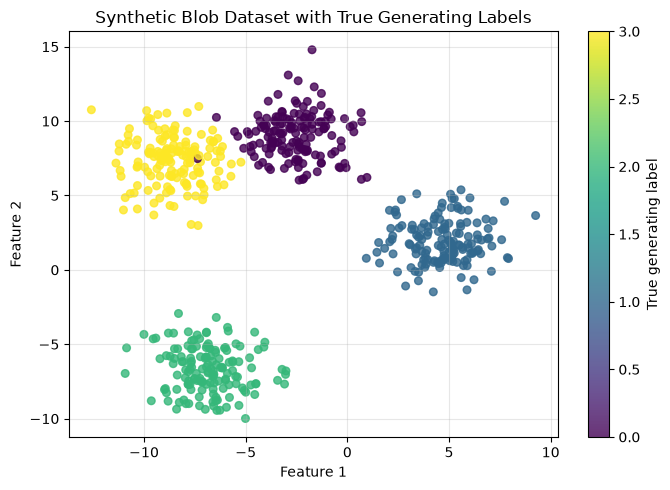

Figure saved successfully at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\01_synthetic_dataset_true_labels.png


In [9]:
import matplotlib.pyplot as plt

figure_path = FIGURES_DIR / "01_synthetic_dataset_true_labels.png"

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(
    X_synthetic[:, 0],
    X_synthetic[:, 1],
    c=y_synthetic_true,
    s=30,
    alpha=0.8
)

ax.set_title("Synthetic Blob Dataset with True Generating Labels")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(True, alpha=0.3)

fig.colorbar(scatter, ax=ax, label="True generating label")

fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved successfully at:")
print(figure_path)

Random K-Means
Final inertia: 2587.7891597408243
Number of iterations: 6
Inertia history: [7532.612283381191, 4390.778858046046, 3070.6725350449806, 2628.5725880840555, 2587.9865449674276, 2587.7891597408243]

K-Means++
Final inertia: 2587.7891597408243
Number of iterations: 3
Inertia history: [4152.242441524276, 2587.9336620481135, 2587.7891597408243]


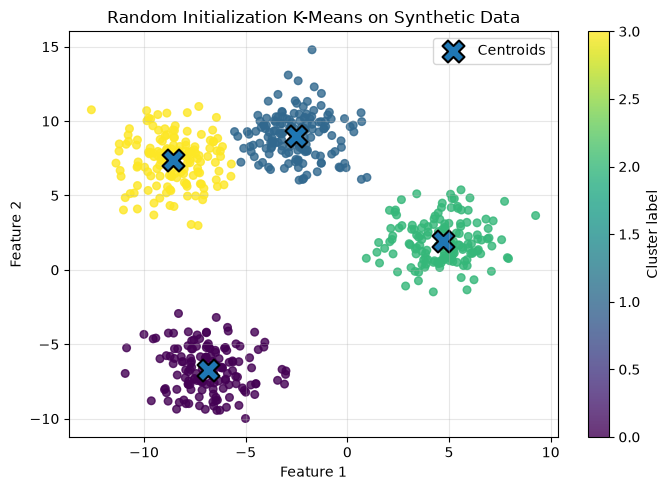

Saved: C:\Users\FATI\Desktop\ml_project_kmeans\figures\02_random_kmeans_synthetic_clusters.png


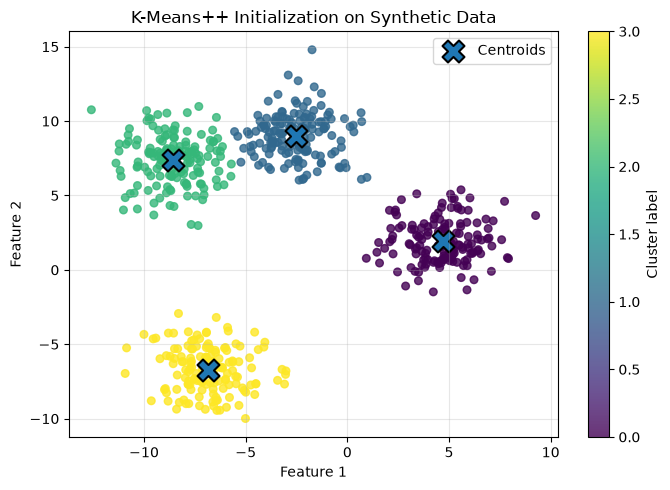

Saved: C:\Users\FATI\Desktop\ml_project_kmeans\figures\03_kmeanspp_synthetic_clusters.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.kmeans import KMeansScratch
from src.kmeanspp import KMeansPlusPlusScratch


def plot_and_save_clusters(X, labels, centers, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 5))

    scatter = ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        s=30,
        alpha=0.8
    )

    ax.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="X",
        s=250,
        edgecolor="black",
        linewidth=1.5,
        label="Centroids"
    )

    fig.colorbar(scatter, ax=ax, label="Cluster label")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


# -----------------------------
# Random initialization K-Means
# -----------------------------
kmeans_random = KMeansScratch(
    n_clusters=4,
    max_iter=300,
    tol=1e-4,
    random_state=7
)

kmeans_random.fit(X_synthetic)

# -----------------------------
# K-Means++ initialization
# -----------------------------
kmeans_pp = KMeansPlusPlusScratch(
    n_clusters=4,
    max_iter=300,
    tol=1e-4,
    random_state=7
)

kmeans_pp.fit(X_synthetic)

# -----------------------------
# Print numerical results
# -----------------------------
print("Random K-Means")
print("Final inertia:", kmeans_random.inertia_)
print("Number of iterations:", kmeans_random.n_iter_)
print("Inertia history:", kmeans_random.inertia_history_)

print("\nK-Means++")
print("Final inertia:", kmeans_pp.inertia_)
print("Number of iterations:", kmeans_pp.n_iter_)
print("Inertia history:", kmeans_pp.inertia_history_)

# -----------------------------
# Save plots
# -----------------------------
plot_and_save_clusters(
    X_synthetic,
    kmeans_random.labels_,
    kmeans_random.cluster_centers_,
    "Random Initialization K-Means on Synthetic Data",
    FIGURES_DIR / "02_random_kmeans_synthetic_clusters.png"
)

plot_and_save_clusters(
    X_synthetic,
    kmeans_pp.labels_,
    kmeans_pp.cluster_centers_,
    "K-Means++ Initialization on Synthetic Data",
    FIGURES_DIR / "03_kmeanspp_synthetic_clusters.png"
)

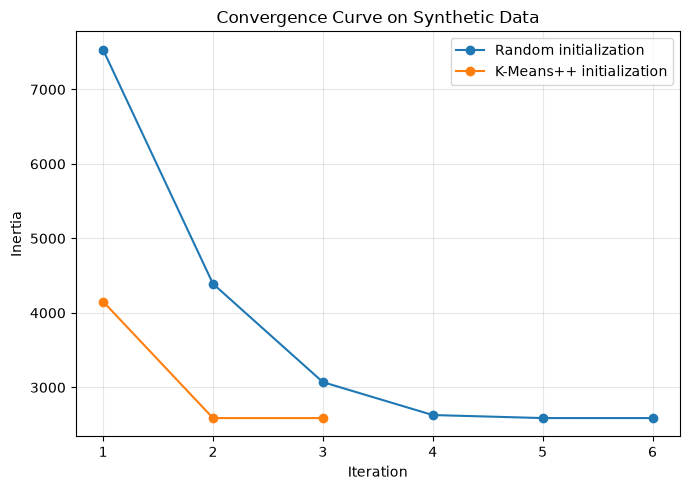

Random K-Means inertia history:
[7532.612283381191, 4390.778858046046, 3070.6725350449806, 2628.5725880840555, 2587.9865449674276, 2587.7891597408243]

K-Means++ inertia history:
[4152.242441524276, 2587.9336620481135, 2587.7891597408243]

Figure saved successfully at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\04_convergence_synthetic_random_vs_kmeanspp.png


In [11]:
import matplotlib.pyplot as plt

figure_path = FIGURES_DIR / "04_convergence_synthetic_random_vs_kmeanspp.png"

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    range(1, len(kmeans_random.inertia_history_) + 1),
    kmeans_random.inertia_history_,
    marker="o",
    label="Random initialization"
)

ax.plot(
    range(1, len(kmeans_pp.inertia_history_) + 1),
    kmeans_pp.inertia_history_,
    marker="o",
    label="K-Means++ initialization"
)

ax.set_title("Convergence Curve on Synthetic Data")
ax.set_xlabel("Iteration")
ax.set_ylabel("Inertia")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Random K-Means inertia history:")
print(kmeans_random.inertia_history_)

print("\nK-Means++ inertia history:")
print(kmeans_pp.inertia_history_)

print("\nFigure saved successfully at:")
print(figure_path)

In [12]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = PROJECT_ROOT / "report"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.kmeans import KMeansScratch
from src.kmeanspp import KMeansPlusPlusScratch

# Number of independent runs
n_runs = 30
seeds = range(n_runs)

results = []

for seed in seeds:
    # Random initialization
    model_random = KMeansScratch(
        n_clusters=4,
        max_iter=300,
        tol=1e-4,
        random_state=seed
    )
    model_random.fit(X_synthetic)

    results.append({
        "dataset": "synthetic_std_1.5",
        "method": "Random",
        "seed": seed,
        "final_inertia": model_random.inertia_,
        "n_iterations": model_random.n_iter_
    })

    # K-Means++ initialization
    model_pp = KMeansPlusPlusScratch(
        n_clusters=4,
        max_iter=300,
        tol=1e-4,
        random_state=seed
    )
    model_pp.fit(X_synthetic)

    results.append({
        "dataset": "synthetic_std_1.5",
        "method": "K-Means++",
        "seed": seed,
        "final_inertia": model_pp.inertia_,
        "n_iterations": model_pp.n_iter_
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Create summary table
summary_df = (
    results_df
    .groupby("method")
    .agg(
        mean_inertia=("final_inertia", "mean"),
        std_inertia=("final_inertia", "std"),
        min_inertia=("final_inertia", "min"),
        max_inertia=("final_inertia", "max"),
        mean_iterations=("n_iterations", "mean"),
        std_iterations=("n_iterations", "std"),
        min_iterations=("n_iterations", "min"),
        max_iterations=("n_iterations", "max")
    )
    .reset_index()
)

# Save tables for report
results_csv_path = REPORT_DIR / "synthetic_stability_results.csv"
summary_csv_path = REPORT_DIR / "synthetic_stability_summary.csv"

results_df.to_csv(results_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)

print("Multiple-runs experiment completed successfully.")
print("\nFirst 10 rows of results:")
print(results_df.head(10).to_string(index=False))

print("\nSummary table:")
print(summary_df.to_string(index=False))

print("\nSaved detailed results at:")
print(results_csv_path)

print("\nSaved summary table at:")
print(summary_csv_path)

Multiple-runs experiment completed successfully.

First 10 rows of results:
          dataset    method  seed  final_inertia  n_iterations
synthetic_std_1.5    Random     0    2587.789160             6
synthetic_std_1.5 K-Means++     0    2587.789160             4
synthetic_std_1.5    Random     1    2587.789160             5
synthetic_std_1.5 K-Means++     1    2587.789160             4
synthetic_std_1.5    Random     2    2587.789160             9
synthetic_std_1.5 K-Means++     2    2587.789160            10
synthetic_std_1.5    Random     3    2587.789160             9
synthetic_std_1.5 K-Means++     3    2587.789160             5
synthetic_std_1.5    Random     4    2587.789160             7
synthetic_std_1.5 K-Means++     4    5251.242668             8

Summary table:
   method  mean_inertia  std_inertia  min_inertia  max_inertia  mean_iterations  std_iterations  min_iterations  max_iterations
K-Means++   3484.625643  1290.080298   2587.78916  5325.707817         6.033333        

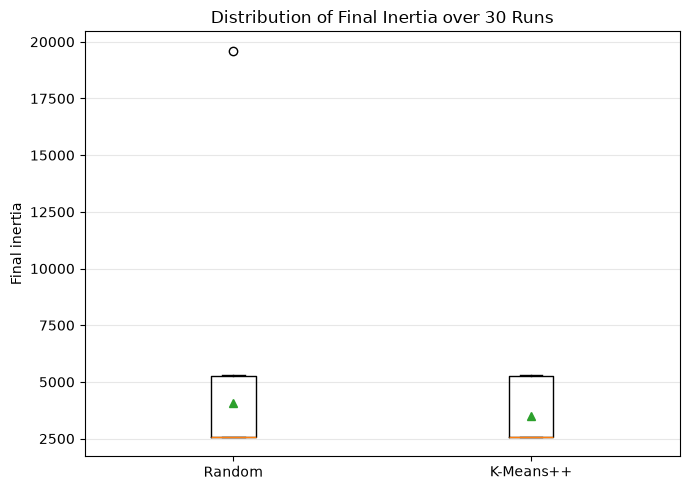

Inertia boxplot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\05_boxplot_inertia_synthetic.png


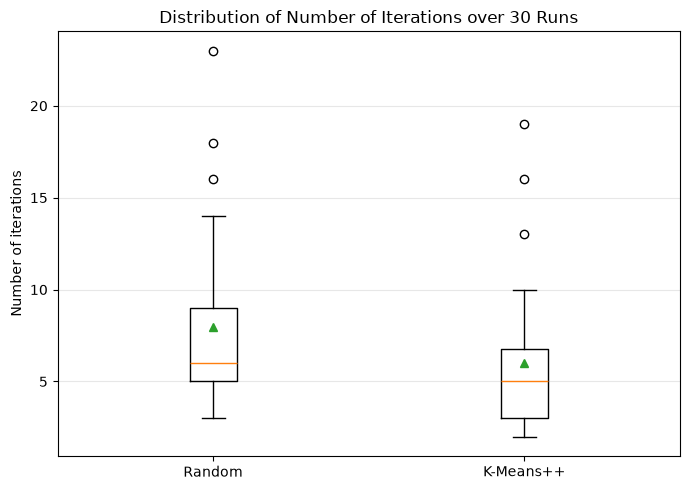


Iterations boxplot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\06_boxplot_iterations_synthetic.png


In [13]:
import matplotlib.pyplot as plt

# Separate results by method
random_results = results_df[results_df["method"] == "Random"]
pp_results = results_df[results_df["method"] == "K-Means++"]

# -----------------------------
# Boxplot 1: Final inertia
# -----------------------------
figure_path_inertia = FIGURES_DIR / "05_boxplot_inertia_synthetic.png"

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        random_results["final_inertia"],
        pp_results["final_inertia"]
    ],
    tick_labels=["Random", "K-Means++"],
    showmeans=True
)

ax.set_title("Distribution of Final Inertia over 30 Runs")
ax.set_ylabel("Final inertia")
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_inertia, dpi=300, bbox_inches="tight")
plt.show()

print("Inertia boxplot saved at:")
print(figure_path_inertia)


# -----------------------------
# Boxplot 2: Number of iterations
# -----------------------------
figure_path_iterations = FIGURES_DIR / "06_boxplot_iterations_synthetic.png"

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        random_results["n_iterations"],
        pp_results["n_iterations"]
    ],
    tick_labels=["Random", "K-Means++"],
    showmeans=True
)

ax.set_title("Distribution of Number of Iterations over 30 Runs")
ax.set_ylabel("Number of iterations")
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_iterations, dpi=300, bbox_inches="tight")
plt.show()

print("\nIterations boxplot saved at:")
print(figure_path_iterations)

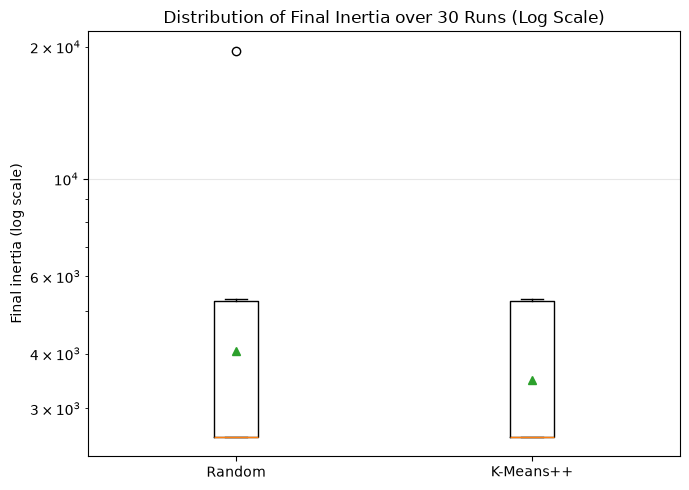

Log-scale inertia boxplot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\07_boxplot_inertia_synthetic_log_scale.png


In [14]:
import matplotlib.pyplot as plt

figure_path_log_inertia = FIGURES_DIR / "07_boxplot_inertia_synthetic_log_scale.png"

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        random_results["final_inertia"],
        pp_results["final_inertia"]
    ],
    tick_labels=["Random", "K-Means++"],
    showmeans=True
)

ax.set_yscale("log")
ax.set_title("Distribution of Final Inertia over 30 Runs (Log Scale)")
ax.set_ylabel("Final inertia (log scale)")
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_log_inertia, dpi=300, bbox_inches="tight")

plt.show()

print("Log-scale inertia boxplot saved at:")
print(figure_path_log_inertia)

In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = PROJECT_ROOT / "report"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.kmeans import KMeansScratch
from src.kmeanspp import KMeansPlusPlusScratch

cluster_stds = [0.5, 1.5, 2.5]
n_runs = 30

overlap_results = []

for cluster_std in cluster_stds:
    X_overlap, y_overlap_true = make_blobs(
        n_samples=600,
        centers=4,
        n_features=2,
        cluster_std=cluster_std,
        random_state=42
    )

    for seed in range(n_runs):
        # Random initialization
        model_random = KMeansScratch(
            n_clusters=4,
            max_iter=300,
            tol=1e-4,
            random_state=seed
        )
        model_random.fit(X_overlap)

        overlap_results.append({
            "cluster_std": cluster_std,
            "method": "Random",
            "seed": seed,
            "final_inertia": model_random.inertia_,
            "n_iterations": model_random.n_iter_
        })

        # K-Means++ initialization
        model_pp = KMeansPlusPlusScratch(
            n_clusters=4,
            max_iter=300,
            tol=1e-4,
            random_state=seed
        )
        model_pp.fit(X_overlap)

        overlap_results.append({
            "cluster_std": cluster_std,
            "method": "K-Means++",
            "seed": seed,
            "final_inertia": model_pp.inertia_,
            "n_iterations": model_pp.n_iter_
        })

overlap_df = pd.DataFrame(overlap_results)

overlap_summary_df = (
    overlap_df
    .groupby(["cluster_std", "method"])
    .agg(
        mean_inertia=("final_inertia", "mean"),
        std_inertia=("final_inertia", "std"),
        min_inertia=("final_inertia", "min"),
        max_inertia=("final_inertia", "max"),
        mean_iterations=("n_iterations", "mean"),
        std_iterations=("n_iterations", "std")
    )
    .reset_index()
)

# Save results
overlap_results_path = REPORT_DIR / "overlap_experiment_results.csv"
overlap_summary_path = REPORT_DIR / "overlap_experiment_summary.csv"

overlap_df.to_csv(overlap_results_path, index=False)
overlap_summary_df.to_csv(overlap_summary_path, index=False)

print("Overlap experiment completed successfully.")

print("\nSummary table:")
print(overlap_summary_df.to_string(index=False))

print("\nSaved detailed results at:")
print(overlap_results_path)

print("\nSaved summary at:")
print(overlap_summary_path)

Overlap experiment completed successfully.

Summary table:
 cluster_std    method  mean_inertia  std_inertia  min_inertia  max_inertia  mean_iterations  std_iterations
         0.5 K-Means++    393.808953   564.698444   290.709594  3383.690355         2.166667        0.912871
         0.5    Random   2009.221784  3344.081652   290.709594 17832.943074         5.966667        3.624470
         1.5 K-Means++   3484.625643  1290.080298  2587.789160  5325.707817         6.033333        4.038464
         1.5    Random   4051.583899  3204.604982  2587.789160 19610.709606         7.966667        4.498914
         2.5 K-Means++   7129.699648   875.816472  6700.279920  9206.106865        11.100000        4.357712
         2.5    Random   7046.113690   785.853802  6700.279920  8773.800823        12.133333        4.183163

Saved detailed results at:
C:\Users\FATI\Desktop\ml_project_kmeans\report\overlap_experiment_results.csv

Saved summary at:
C:\Users\FATI\Desktop\ml_project_kmeans\report\overla

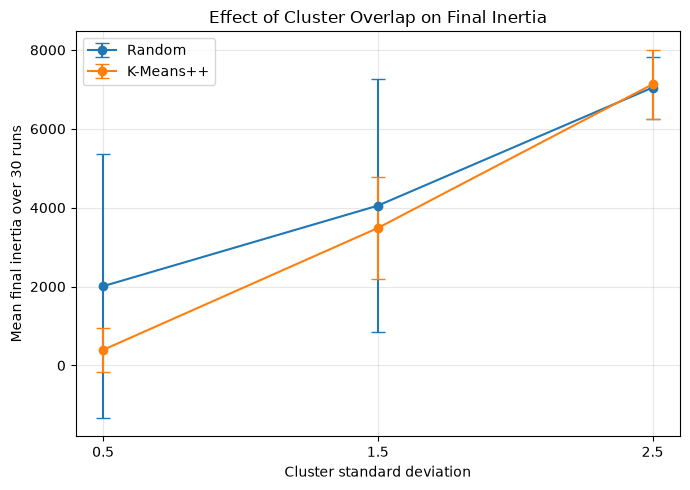

Overlap inertia plot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\08_mean_inertia_vs_cluster_overlap.png


In [16]:
import matplotlib.pyplot as plt

figure_path_overlap_inertia = FIGURES_DIR / "08_mean_inertia_vs_cluster_overlap.png"

fig, ax = plt.subplots(figsize=(7, 5))

for method in ["Random", "K-Means++"]:
    method_data = overlap_summary_df[overlap_summary_df["method"] == method].sort_values("cluster_std")
    
    ax.errorbar(
        method_data["cluster_std"],
        method_data["mean_inertia"],
        yerr=method_data["std_inertia"],
        marker="o",
        capsize=5,
        label=method
    )

ax.set_title("Effect of Cluster Overlap on Final Inertia")
ax.set_xlabel("Cluster standard deviation")
ax.set_ylabel("Mean final inertia over 30 runs")
ax.set_xticks([0.5, 1.5, 2.5])
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_overlap_inertia, dpi=300, bbox_inches="tight")

plt.show()

print("Overlap inertia plot saved at:")
print(figure_path_overlap_inertia)

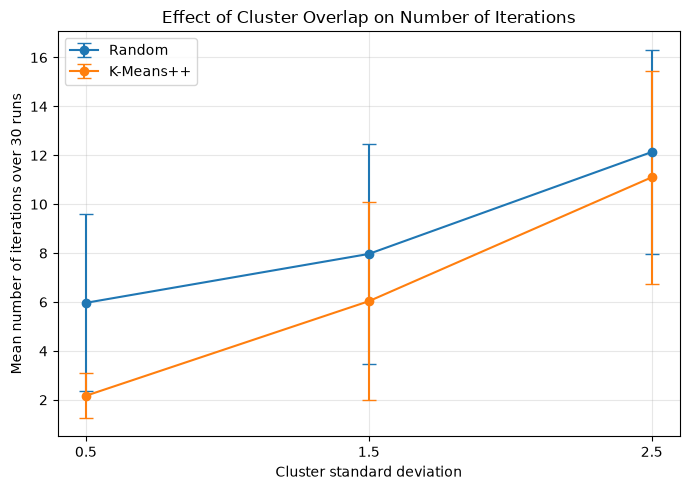

Overlap iterations plot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\09_mean_iterations_vs_cluster_overlap.png


In [17]:
import matplotlib.pyplot as plt

figure_path_overlap_iterations = FIGURES_DIR / "09_mean_iterations_vs_cluster_overlap.png"

fig, ax = plt.subplots(figsize=(7, 5))

for method in ["Random", "K-Means++"]:
    method_data = overlap_summary_df[
        overlap_summary_df["method"] == method
    ].sort_values("cluster_std")
    
    ax.errorbar(
        method_data["cluster_std"],
        method_data["mean_iterations"],
        yerr=method_data["std_iterations"],
        marker="o",
        capsize=5,
        label=method
    )

ax.set_title("Effect of Cluster Overlap on Number of Iterations")
ax.set_xlabel("Cluster standard deviation")
ax.set_ylabel("Mean number of iterations over 30 runs")
ax.set_xticks([0.5, 1.5, 2.5])
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_overlap_iterations, dpi=300, bbox_inches="tight")

plt.show()

print("Overlap iterations plot saved at:")
print(figure_path_overlap_iterations)

In [18]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path

from sklearn.metrics import adjusted_rand_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = PROJECT_ROOT / "report"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.kmeans import KMeansScratch
from src.kmeanspp import KMeansPlusPlusScratch

# Digits has 10 true digit classes: 0, 1, ..., 9
n_clusters_digits = 10
n_runs_digits = 30

digits_results = []

for seed in range(n_runs_digits):
    # -----------------------------
    # Random initialization
    # -----------------------------
    model_random_digits = KMeansScratch(
        n_clusters=n_clusters_digits,
        max_iter=300,
        tol=1e-4,
        random_state=seed
    )
    model_random_digits.fit(X_digits_scaled)

    ari_random = adjusted_rand_score(
        y_digits_true,
        model_random_digits.labels_
    )

    digits_results.append({
        "dataset": "digits",
        "method": "Random",
        "seed": seed,
        "final_inertia": model_random_digits.inertia_,
        "n_iterations": model_random_digits.n_iter_,
        "ARI": ari_random
    })

    # -----------------------------
    # K-Means++ initialization
    # -----------------------------
    model_pp_digits = KMeansPlusPlusScratch(
        n_clusters=n_clusters_digits,
        max_iter=300,
        tol=1e-4,
        random_state=seed
    )
    model_pp_digits.fit(X_digits_scaled)

    ari_pp = adjusted_rand_score(
        y_digits_true,
        model_pp_digits.labels_
    )

    digits_results.append({
        "dataset": "digits",
        "method": "K-Means++",
        "seed": seed,
        "final_inertia": model_pp_digits.inertia_,
        "n_iterations": model_pp_digits.n_iter_,
        "ARI": ari_pp
    })

digits_results_df = pd.DataFrame(digits_results)

digits_summary_df = (
    digits_results_df
    .groupby("method")
    .agg(
        mean_inertia=("final_inertia", "mean"),
        std_inertia=("final_inertia", "std"),
        min_inertia=("final_inertia", "min"),
        max_inertia=("final_inertia", "max"),
        mean_iterations=("n_iterations", "mean"),
        std_iterations=("n_iterations", "std"),
        mean_ARI=("ARI", "mean"),
        std_ARI=("ARI", "std"),
        min_ARI=("ARI", "min"),
        max_ARI=("ARI", "max")
    )
    .reset_index()
)

# Save results
digits_results_path = REPORT_DIR / "digits_experiment_results.csv"
digits_summary_path = REPORT_DIR / "digits_experiment_summary.csv"

digits_results_df.to_csv(digits_results_path, index=False)
digits_summary_df.to_csv(digits_summary_path, index=False)

print("Digits experiment completed successfully.")

print("\nFirst 10 rows:")
print(digits_results_df.head(10).to_string(index=False))

print("\nDigits summary table:")
print(digits_summary_df.to_string(index=False))

print("\nSaved detailed results at:")
print(digits_results_path)

print("\nSaved summary at:")
print(digits_summary_path)

Digits experiment completed successfully.

First 10 rows:
dataset    method  seed  final_inertia  n_iterations      ARI
 digits    Random     0   71849.496599            25 0.514953
 digits K-Means++     0   70505.257102            17 0.472994
 digits    Random     1   69662.110740            20 0.567649
 digits K-Means++     1   72321.750385            19 0.437245
 digits    Random     2   69750.243091            32 0.558110
 digits K-Means++     2   71500.696441            23 0.486014
 digits    Random     3   70678.810926            25 0.563321
 digits K-Means++     3   72791.871124            19 0.344074
 digits    Random     4   69852.514406            49 0.536440
 digits K-Means++     4   72468.131213            16 0.284775

Digits summary table:
   method  mean_inertia  std_inertia  min_inertia  max_inertia  mean_iterations  std_iterations  mean_ARI  std_ARI  min_ARI  max_ARI
K-Means++  71491.330034  1017.540495 69426.017403 72900.588518        22.666667        7.447903  0.44428

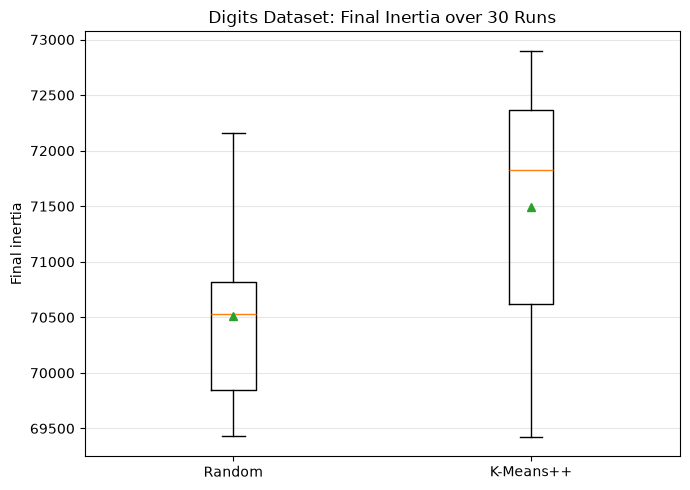

Digits inertia boxplot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\10_boxplot_inertia_digits.png


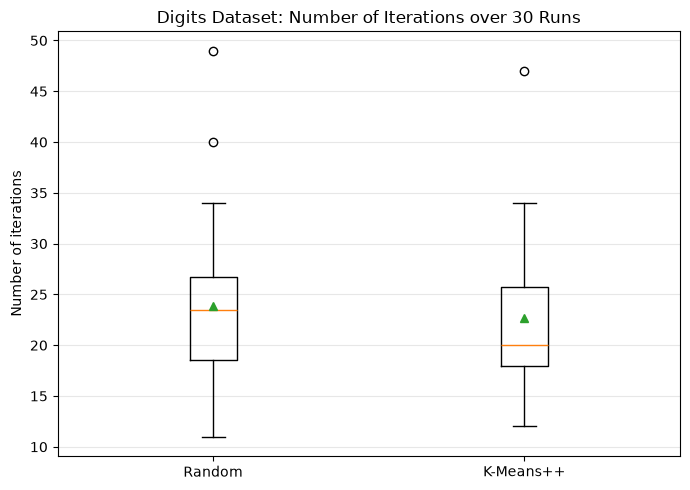


Digits iterations boxplot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\11_boxplot_iterations_digits.png


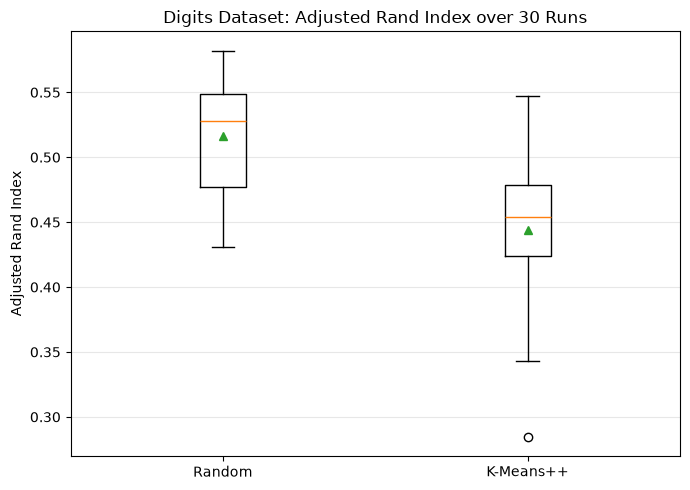


Digits ARI boxplot saved at:
C:\Users\FATI\Desktop\ml_project_kmeans\figures\12_boxplot_ari_digits.png


In [19]:
import matplotlib.pyplot as plt

digits_random = digits_results_df[digits_results_df["method"] == "Random"]
digits_pp = digits_results_df[digits_results_df["method"] == "K-Means++"]

# -----------------------------
# Boxplot 1: Digits final inertia
# -----------------------------
figure_path_digits_inertia = FIGURES_DIR / "10_boxplot_inertia_digits.png"

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        digits_random["final_inertia"],
        digits_pp["final_inertia"]
    ],
    tick_labels=["Random", "K-Means++"],
    showmeans=True
)

ax.set_title("Digits Dataset: Final Inertia over 30 Runs")
ax.set_ylabel("Final inertia")
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_digits_inertia, dpi=300, bbox_inches="tight")
plt.show()

print("Digits inertia boxplot saved at:")
print(figure_path_digits_inertia)


# -----------------------------
# Boxplot 2: Digits iterations
# -----------------------------
figure_path_digits_iterations = FIGURES_DIR / "11_boxplot_iterations_digits.png"

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        digits_random["n_iterations"],
        digits_pp["n_iterations"]
    ],
    tick_labels=["Random", "K-Means++"],
    showmeans=True
)

ax.set_title("Digits Dataset: Number of Iterations over 30 Runs")
ax.set_ylabel("Number of iterations")
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_digits_iterations, dpi=300, bbox_inches="tight")
plt.show()

print("\nDigits iterations boxplot saved at:")
print(figure_path_digits_iterations)


# -----------------------------
# Boxplot 3: Digits ARI
# -----------------------------
figure_path_digits_ari = FIGURES_DIR / "12_boxplot_ari_digits.png"

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        digits_random["ARI"],
        digits_pp["ARI"]
    ],
    tick_labels=["Random", "K-Means++"],
    showmeans=True
)

ax.set_title("Digits Dataset: Adjusted Rand Index over 30 Runs")
ax.set_ylabel("Adjusted Rand Index")
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(figure_path_digits_ari, dpi=300, bbox_inches="tight")
plt.show()

print("\nDigits ARI boxplot saved at:")
print(figure_path_digits_ari)

Original Digits shape: (1797, 64)
2D PCA projection shape: (1797, 2)

Best Random seed by inertia: 21
Best K-Means++ seed by inertia: 10


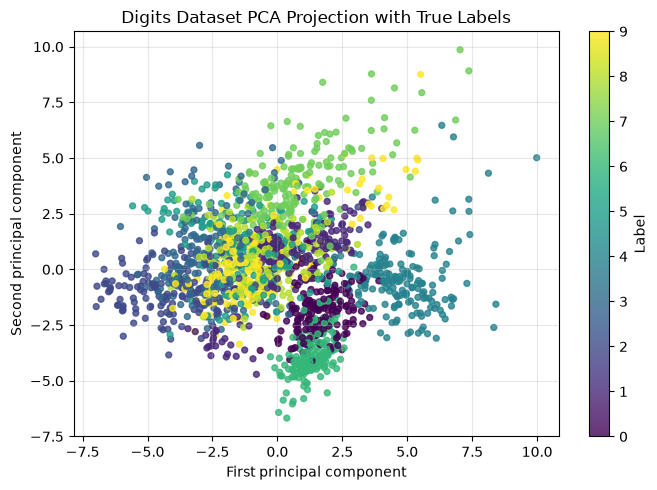

Saved: C:\Users\FATI\Desktop\ml_project_kmeans\figures\13_digits_pca_true_labels.png


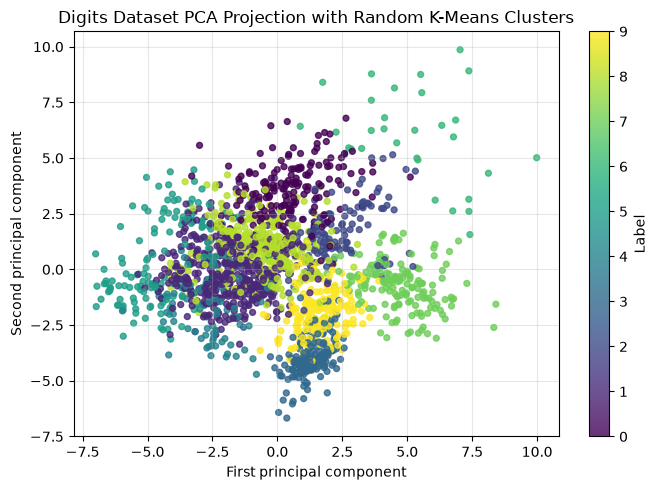

Saved: C:\Users\FATI\Desktop\ml_project_kmeans\figures\14_digits_pca_random_clusters.png


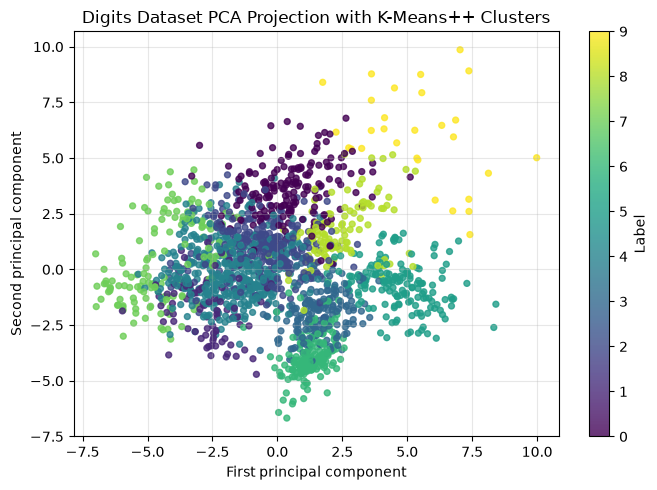

Saved: C:\Users\FATI\Desktop\ml_project_kmeans\figures\15_digits_pca_kmeanspp_clusters.png

Representative model results:
Random inertia: 69428.6504474491
Random iterations: 22
K-Means++ inertia: 69426.01740321837
K-Means++ iterations: 19


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.kmeans import KMeansScratch
from src.kmeanspp import KMeansPlusPlusScratch


def pca_2d_from_scratch(X):
    """
    Project high-dimensional data to 2D using PCA implemented with NumPy SVD.
    This is used only for visualization, not for training K-Means.
    """
    X = np.asarray(X, dtype=float)
    
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    
    # SVD decomposition
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    
    # First two principal directions
    components = Vt[:2]
    
    # 2D projection
    X_2d = X_centered @ components.T
    
    return X_2d


def plot_digits_pca(X_2d, labels, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    scatter = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=labels,
        s=18,
        alpha=0.8
    )
    
    fig.colorbar(scatter, ax=ax, label="Label")
    ax.set_title(title)
    ax.set_xlabel("First principal component")
    ax.set_ylabel("Second principal component")
    ax.grid(True, alpha=0.3)
    
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", save_path)


# -----------------------------
# PCA projection from scratch
# -----------------------------
X_digits_pca_2d = pca_2d_from_scratch(X_digits_scaled)

print("Original Digits shape:", X_digits_scaled.shape)
print("2D PCA projection shape:", X_digits_pca_2d.shape)


# -----------------------------
# Choose representative seeds
# Use the best-inertia seed for each method
# -----------------------------
best_random_seed = int(
    digits_results_df[digits_results_df["method"] == "Random"]
    .sort_values("final_inertia")
    .iloc[0]["seed"]
)

best_pp_seed = int(
    digits_results_df[digits_results_df["method"] == "K-Means++"]
    .sort_values("final_inertia")
    .iloc[0]["seed"]
)

print("\nBest Random seed by inertia:", best_random_seed)
print("Best K-Means++ seed by inertia:", best_pp_seed)


# -----------------------------
# Fit representative models again
# -----------------------------
best_random_model_digits = KMeansScratch(
    n_clusters=10,
    max_iter=300,
    tol=1e-4,
    random_state=best_random_seed
)
best_random_model_digits.fit(X_digits_scaled)

best_pp_model_digits = KMeansPlusPlusScratch(
    n_clusters=10,
    max_iter=300,
    tol=1e-4,
    random_state=best_pp_seed
)
best_pp_model_digits.fit(X_digits_scaled)


# -----------------------------
# Save PCA visualizations
# -----------------------------
plot_digits_pca(
    X_digits_pca_2d,
    y_digits_true,
    "Digits Dataset PCA Projection with True Labels",
    FIGURES_DIR / "13_digits_pca_true_labels.png"
)

plot_digits_pca(
    X_digits_pca_2d,
    best_random_model_digits.labels_,
    "Digits Dataset PCA Projection with Random K-Means Clusters",
    FIGURES_DIR / "14_digits_pca_random_clusters.png"
)

plot_digits_pca(
    X_digits_pca_2d,
    best_pp_model_digits.labels_,
    "Digits Dataset PCA Projection with K-Means++ Clusters",
    FIGURES_DIR / "15_digits_pca_kmeanspp_clusters.png"
)

print("\nRepresentative model results:")
print("Random inertia:", best_random_model_digits.inertia_)
print("Random iterations:", best_random_model_digits.n_iter_)
print("K-Means++ inertia:", best_pp_model_digits.inertia_)
print("K-Means++ iterations:", best_pp_model_digits.n_iter_)

In [21]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = PROJECT_ROOT / "report"

# -----------------------------
# 1. Synthetic stability summary
# -----------------------------
synthetic_table = summary_df.copy()

synthetic_table = synthetic_table[
    [
        "method",
        "mean_inertia",
        "std_inertia",
        "min_inertia",
        "max_inertia",
        "mean_iterations",
        "std_iterations"
    ]
]

synthetic_table = synthetic_table.round(3)

synthetic_csv_path = REPORT_DIR / "table_1_synthetic_stability_summary.csv"
synthetic_tex_path = REPORT_DIR / "table_1_synthetic_stability_summary.tex"

synthetic_table.to_csv(synthetic_csv_path, index=False)
synthetic_table.to_latex(
    synthetic_tex_path,
    index=False,
    caption="Stability comparison on the synthetic dataset over 30 independent runs.",
    label="tab:synthetic_stability"
)


# -----------------------------
# 2. Overlap experiment summary
# -----------------------------
overlap_table = overlap_summary_df.copy()

overlap_table = overlap_table[
    [
        "cluster_std",
        "method",
        "mean_inertia",
        "std_inertia",
        "mean_iterations",
        "std_iterations"
    ]
]

overlap_table = overlap_table.round(3)

overlap_csv_path = REPORT_DIR / "table_2_overlap_summary.csv"
overlap_tex_path = REPORT_DIR / "table_2_overlap_summary.tex"

overlap_table.to_csv(overlap_csv_path, index=False)
overlap_table.to_latex(
    overlap_tex_path,
    index=False,
    caption="Effect of cluster overlap on inertia and convergence over 30 independent runs.",
    label="tab:overlap_summary"
)


# -----------------------------
# 3. Digits experiment summary
# -----------------------------
digits_table = digits_summary_df.copy()

digits_table = digits_table[
    [
        "method",
        "mean_inertia",
        "std_inertia",
        "mean_iterations",
        "std_iterations",
        "mean_ARI",
        "std_ARI"
    ]
]

digits_table = digits_table.round(3)

digits_csv_path = REPORT_DIR / "table_3_digits_summary.csv"
digits_tex_path = REPORT_DIR / "table_3_digits_summary.tex"

digits_table.to_csv(digits_csv_path, index=False)
digits_table.to_latex(
    digits_tex_path,
    index=False,
    caption="Comparison on the high-dimensional Digits dataset over 30 independent runs.",
    label="tab:digits_summary"
)


print("Final report tables created successfully.")

print("\nTable 1: Synthetic stability")
print(synthetic_table.to_string(index=False))

print("\nTable 2: Overlap experiment")
print(overlap_table.to_string(index=False))

print("\nTable 3: Digits experiment")
print(digits_table.to_string(index=False))

print("\nSaved LaTeX tables:")
print(synthetic_tex_path)
print(overlap_tex_path)
print(digits_tex_path)

Final report tables created successfully.

Table 1: Synthetic stability
   method  mean_inertia  std_inertia  min_inertia  max_inertia  mean_iterations  std_iterations
K-Means++      3484.626     1290.080     2587.789     5325.708            6.033           4.038
   Random      4051.584     3204.605     2587.789    19610.710            7.967           4.499

Table 2: Overlap experiment
 cluster_std    method  mean_inertia  std_inertia  mean_iterations  std_iterations
         0.5 K-Means++       393.809      564.698            2.167           0.913
         0.5    Random      2009.222     3344.082            5.967           3.624
         1.5 K-Means++      3484.626     1290.080            6.033           4.038
         1.5    Random      4051.584     3204.605            7.967           4.499
         2.5 K-Means++      7129.700      875.816           11.100           4.358
         2.5    Random      7046.114      785.854           12.133           4.183

Table 3: Digits experiment
  

In [22]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORT_DIR = PROJECT_ROOT / "report"
SRC_DIR = PROJECT_ROOT / "src"

expected_files = [
    # Source files
    SRC_DIR / "kmeans.py",
    SRC_DIR / "kmeanspp.py",
    SRC_DIR / "utils.py",
    
    # Main figures
    FIGURES_DIR / "01_synthetic_dataset_true_labels.png",
    FIGURES_DIR / "02_random_kmeans_synthetic_clusters.png",
    FIGURES_DIR / "03_kmeanspp_synthetic_clusters.png",
    FIGURES_DIR / "04_convergence_synthetic_random_vs_kmeanspp.png",
    FIGURES_DIR / "05_boxplot_inertia_synthetic.png",
    FIGURES_DIR / "06_boxplot_iterations_synthetic.png",
    FIGURES_DIR / "07_boxplot_inertia_synthetic_log_scale.png",
    FIGURES_DIR / "08_mean_inertia_vs_cluster_overlap.png",
    FIGURES_DIR / "09_mean_iterations_vs_cluster_overlap.png",
    FIGURES_DIR / "10_boxplot_inertia_digits.png",
    FIGURES_DIR / "11_boxplot_iterations_digits.png",
    FIGURES_DIR / "12_boxplot_ari_digits.png",
    FIGURES_DIR / "13_digits_pca_true_labels.png",
    FIGURES_DIR / "14_digits_pca_random_clusters.png",
    FIGURES_DIR / "15_digits_pca_kmeanspp_clusters.png",
    
    # CSV results
    REPORT_DIR / "synthetic_stability_results.csv",
    REPORT_DIR / "synthetic_stability_summary.csv",
    REPORT_DIR / "overlap_experiment_results.csv",
    REPORT_DIR / "overlap_experiment_summary.csv",
    REPORT_DIR / "digits_experiment_results.csv",
    REPORT_DIR / "digits_experiment_summary.csv",
    
    # LaTeX tables
    REPORT_DIR / "table_1_synthetic_stability_summary.tex",
    REPORT_DIR / "table_2_overlap_summary.tex",
    REPORT_DIR / "table_3_digits_summary.tex",
    
    # Project files
    PROJECT_ROOT / "requirements.txt",
    PROJECT_ROOT / "README.md",
]

missing_files = []
existing_files = []

for file_path in expected_files:
    if file_path.exists():
        existing_files.append(file_path)
    else:
        missing_files.append(file_path)

print("Project file audit completed.")
print("\nExisting files:", len(existing_files))
print("Missing files:", len(missing_files))

if missing_files:
    print("\nMissing files:")
    for file_path in missing_files:
        print("-", file_path.relative_to(PROJECT_ROOT))
else:
    print("\nAll expected files exist. Project structure is complete.")

print("\nExisting figure files:")
for fig_path in sorted(FIGURES_DIR.glob("*.png")):
    print("-", fig_path.name)

Project file audit completed.

Existing files: 29
Missing files: 0

All expected files exist. Project structure is complete.

Existing figure files:
- 01_synthetic_dataset_true_labels.png
- 02_random_kmeans_synthetic_clusters.png
- 03_kmeanspp_synthetic_clusters.png
- 04_convergence_synthetic_random_vs_kmeanspp.png
- 05_boxplot_inertia_synthetic.png
- 06_boxplot_iterations_synthetic.png
- 07_boxplot_inertia_synthetic_log_scale.png
- 08_mean_inertia_vs_cluster_overlap.png
- 09_mean_iterations_vs_cluster_overlap.png
- 10_boxplot_inertia_digits.png
- 11_boxplot_iterations_digits.png
- 12_boxplot_ari_digits.png
- 13_digits_pca_true_labels.png
- 14_digits_pca_random_clusters.png
- 15_digits_pca_kmeanspp_clusters.png
